In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.datasets import load_boston

In [3]:
datas = load_boston()

In [7]:
data = pd.DataFrame(datas.data,columns = datas.feature_names)

In [8]:
data.head()
# Ultimate aim to remove all the correlated values.

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [10]:
data['MEDV'] = datas.target

In [11]:
X = data.drop('MEDV',axis = 1)
y = data['MEDV']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


<AxesSubplot:>

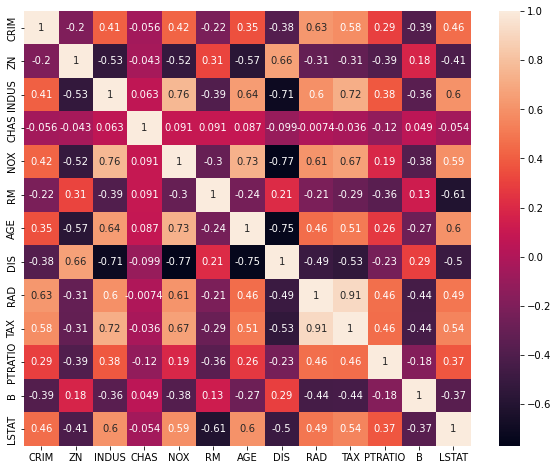

In [26]:
plt.figure(figsize = (10,8))
sns.heatmap(X.corr(),annot = True)
# its pearson correlation.


In [45]:
def correlation(dataset, threshold):
    coll_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                coll_corr.add(colname)
    return coll_corr
    # nothing but we have a for loop that will eliminate the highly correlated features, it's easy
    # ---- code only look properly !

In [47]:
correlation(X_train, 0.8)

{'TAX'}

In [48]:
# Threshod can be set by ourself, we can say hyper parameter tunning!

In [49]:
# after this we use can drop the values and we use for model building!


In [50]:
# Why we do separetly coz we need to overcome the Overfitting conditions.!

In [51]:
corr_features = correlation(X_train, 0.6)
len(set(corr_features))

6

In [52]:
corr_features

{'AGE', 'DIS', 'LSTAT', 'NOX', 'RAD', 'TAX'}

In [57]:
X_train = X_train.drop(corr_features, axis = 1)
# otherwise we can drop the data from the whole dataset and we can train our model.